Bu hafta öğreneceklerin:

- Embedding: harfi one-hot vektör yerine öğrenilen küçük bir vektörle temsil etmek
- Bağlam penceresi: bir harf yerine önceki üç harfe bakan model
- Minibatch ile eğitim ve learning rate seçimi
- Train / dev / test ayrımı ve neden gerektiği
- Tanh saturation: aktivasyonlar 1 ve -1'e yığılınca gradient'in ölmesi
- Kaiming init: ağırlıkları hangi ölçekte başlatmak gerektiği
- BatchNorm: aktivasyonları katman katman normalize etmek ve bunun eğitime etkisi


### Görev 1
 Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3 harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur, indeksleme ile embedding'leri çek. (Part 2, 9:03 - 18:35)


BAĞLAM PENCERESİ (CONTEXT WINDOW) İLE VERİ SETİNİ KURMA:
    Modelin tek bir harf yerine önceki 3 harfe bakarak sıradakini tahmin etmesini istiyoruz.

    block_size = 3: Bir harfi tahmin etmek için geriye doğru aldığımız bağlam (context) uzunluğu.

    X: Modelin girdisi (önceki 3 harfin indeksleri) -> Boyut: (N, 3)

    Y: Modelin tahmin etmesi gereken hedef harfin indeksi -> Boyut: (N,)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 
X, Y = [], []

# Konsepti gözle takip edebilmek için Karpathy gibi önce ilk 5 ismi alıyoruz:
for w in words[:5]:
  print(w)
  # Başlangıçta henüz hiç harf görmediğimiz için bağlamı 3 adet nokta (0) ile dolduruyoruz: [...]
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    # Kayan pencere (sliding window): En eski harfi atıp yeni harfi bağlama ekliyoruz
    context = context[1:] + [ix]
  
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
# göresel olarak X ve Y görelim
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [8]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [9]:
C = torch.randn((27, 2)) # 27 characters in the vocab, 2-dimensional embeddings
C

tensor([[-0.9329,  0.2983],
        [ 0.0919, -0.0402],
        [-1.1468,  1.3822],
        [ 0.1491, -0.2682],
        [-0.8917,  1.4900],
        [-0.7854,  0.1064],
        [-0.0146,  0.2206],
        [-0.2555,  0.4915],
        [-0.1351,  2.2123],
        [ 0.7225,  3.2569],
        [-0.5701,  0.0753],
        [-0.8237,  0.2381],
        [-0.5280,  0.5533],
        [-1.2305, -0.6917],
        [-1.1711,  0.8159],
        [ 0.8046,  0.1304],
        [-1.2131, -1.2898],
        [-0.4729, -0.2708],
        [ 1.6937, -0.0892],
        [-0.9683, -1.8254],
        [ 0.3937, -0.4444],
        [-0.7445,  0.9544],
        [ 0.1245, -1.3425],
        [ 0.0836, -0.2365],
        [-1.2179,  2.3682],
        [ 1.3372, -0.0495],
        [-0.3107,  1.3479]])

In [10]:
# one hot encoding of the 5th character in the vocabulary (which is 'e' in this case)
# sinir ağını beslemek için one-hot encoding kullanıyoruz. Bu, karakterin hangi sınıfa ait olduğunu belirtmek için kullanılır.
# örnek olarak bir karakterin one-hot encoding'ini alalım ve embedding matrisimizle çarpalım. Bu, karakterin embedding vektörünü elde etmemizi sağlar.
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

#burada tek boyutlu bir tensor ile embedding matrisimizi çarptık ve karakterin embedding vektörünü elde ettik.
#karpathynin söylediği gibi tek bir satır da, tüm listeleri tek seferde embedding matrisimizle çarpabiliriz.
# embedding matrisimizle çarpma işlemi, karakterin embedding vektörünü elde etmemizi sağlar. 
# Bu, sinir ağımızın karakterleri daha anlamlı bir şekilde temsil etmesine yardımcı olur.


tensor([-0.7854,  0.1064])

In [11]:
# EMBEDDING (GÖMME) TABLOSU VE İNDEKSLEME MANTIĞI
# ==================================================
# İng alfabemizde 27 karakter var. Her karaktere rastgele 2 boyutlu bir koordinat (vektör) atıyoruz.
# C: (27, 2) boyutunda öğrenilebilir ağırlık matrisimizdir.
C = torch.randn((27, 2))

# --- ÖNEMLİ TEORİK DETAY (One-Hot vs Embedding Lookup) ---
# Geçen hafta girdi harfini 27 boyutlu one-hot vektör yapıp ağırlıkla çarpıyorduk.
# Örneğin 5. indeksteki 'e' harfi için:
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C
# Fakat sıfırlarla dolu bir vektörü çarpmak matematiksel olarak C matrisinin 
# 5. satırını doğrudan çekmekle (C[5]) tamamen aynı sonucu verir!
# Bu yüzden çarpma yapmak yerine doğrudan indeksleme (Lookup) kullanıyoruz:
print("One-hot çarpımı sonucu :", (F.one_hot(torch.tensor(5), num_classes=27).float() @ C))
print("Doğrudan C[5] sonucu     :", C[5])

One-hot çarpımı sonucu : tensor([-0.4171,  0.5340])
Doğrudan C[5] sonucu     : tensor([-0.4171,  0.5340])


In [12]:
# TÜM GİRDİLERİ TEK SEFERDE VEKTÖRLEŞTİRME
# ===============================================
# PyTorch'un gelişmiş indeksleme (array indexing) yeteneği sayesinde:
# X tensörümüz (32, 3) boyutundayken, C[X] yazdığımızda PyTorch X'teki her bir tamsayıyı
# C matrisinden 2 boyutlu vektörüyle değiştirir.
# Çıktı boyutu: (32, 3, 2)
# Yani 32 eğitim örneği, her örnekte 3 harf ve her harf için 2 boyutlu bir vektör.
emb = C[X]
print("Embedding tensör boyutu (Örnek Sayısı, Pencere, Vektör Boyutu):", emb.shape)

Embedding tensör boyutu (Örnek Sayısı, Pencere, Vektör Boyutu): torch.Size([32, 3, 2])


### Görev 2
Gizli katmanı ve çıkış katmanını kur: embedding'leri düzleştir, W1 ve b1 ile tanh, W2 ve b2 ile logits. Loss'u geçen haftaki gibi elle hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster ve neden onu tercih ettiğimizi videodan anla. (18:35 - 37:56)

Gizli Katmanı (MLP) Kurmak ve F.cross_entropy:



In [ ]:
#her bir karakterin embedding vektörünü alıp, onları tek bir vektörde birleştirmek. Bu, sinir ağımızın girdi olarak alacağı karakterlerin temsilini oluşturur. 
#Daha sonra bu vektörü, ağırlık matrisi W1 ile çarpıyoruz ve bias b1 ekliyoruz. Bu işlem, sinir ağımızın ilk katmanının çıktısını elde etmemizi sağlar.

W1 = torch.randn((block_size * 2, 100)) # 100 hidden neurons
b1 = torch.randn(100)

#emb @ W1 + b1 #yapmak istediğimiz şey bu ancak 6 x 100 matris ile 32 x 3 x 2 matrisi çarpamayız,


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x30 and 6x100)

In [14]:
#torchun cat fonksiyonu ile 32 x 3 x 2 matrisini 32 x 6 matrisine dönüştürebiliriz. Bu sayede emb @ W1 + b1 işlemini gerçekleştirebiliriz.
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], dim=1).shape

#torch.cat çalışır ama dim=1 boyunca yeni bir tensör üretip belleği kopyalar. Bunun yerine belleği kopyalamayan, 
# sadece tensörün okuma şeklini değiştiren emb.view(-1, 6) kullanmalıyız

#çıktımzıın 32 x 6 matris olmalı
#emb.shape #(32, 3, 2) olmalı

torch.Size([32, 6])

In [15]:
emb.view(32,6) @ W1 + b1

tensor([[ 0.1732, -0.2590, -0.4990,  ...,  0.9539,  2.9634, -1.8197],
        [-0.4733,  0.7739,  1.5072,  ...,  0.9932,  2.1024, -1.3931],
        [ 3.0740,  0.2646, -0.7008,  ...,  0.3144,  0.1512,  0.3540],
        ...,
        [ 1.0755,  1.3974,  1.0053,  ...,  0.4247,  0.8620,  0.4569],
        [ 0.9250,  0.9531,  0.2334,  ...,  0.8302,  1.2168,  0.4001],
        [ 4.3460, -1.0642, -2.9892,  ...,  2.2104, -0.6831, -0.2083]])

In [16]:
h = emb.view(32,6) @ W1 + b1 

# gizli katman çıktısı h'nin boyutunu kontrol edelim
h.shape

torch.Size([32, 100])

In [17]:
#tabi ki tanh almamız gerekir. Çünkü sinir ağımızın ilk katmanının çıktısını elde ettik ve bu çıktıyı aktivasyon fonksiyonuna sokmamız gerekiyor. 
# Tanh, -1 ile 1 arasında değerler üreten bir aktivasyon fonksiyonudur ve sinir ağımızın öğrenme sürecinde önemli bir rol oynar.
h = torch.tanh(h)

h.shape 

torch.Size([32, 100])

In [18]:
W2 = torch.randn((100, 27)) # 27 output classes
b2 = torch.randn(27) 

logits = h @ W2 + b2

logits.shape

torch.Size([32, 27])

In [19]:
counts = logits.exp() # softmax için exp alıyoruz

prob = counts / counts.sum(1, keepdims=True) # softmax

prob.shape

torch.Size([32, 27])

In [20]:
prob[0].sum() #her bir satırın toplamı 1 olmalı, çünkü softmax yaptık

tensor(1.)

In [21]:
prob[torch.arange(32), Y] #her bir satırın doğru sınıfının olasılığı

tensor([3.1362e-09, 7.3227e-01, 6.4228e-01, 9.6752e-10, 2.0494e-11, 3.7295e-10,
        5.1430e-08, 1.2477e-05, 1.1640e-09, 9.9912e-01, 4.4263e-09, 9.2968e-08,
        9.5398e-06, 1.3072e-07, 4.2865e-10, 1.4560e-09, 1.8974e-07, 7.2605e-06,
        7.1216e-07, 3.0214e-05, 3.0222e-10, 1.4744e-13, 3.2594e-07, 6.5845e-06,
        2.1795e-13, 6.1329e-04, 6.8673e-08, 1.0795e-17, 5.3099e-11, 9.4384e-05,
        2.9294e-08, 4.9957e-09])

In [22]:

loss = -prob[torch.arange(32), Y].log().mean() #negatif log olasılıkların ortalaması

loss

tensor(16.6412)

In [23]:
# şimdi bazzı kavramları anladığımıza göre görev için tam halini kurgulayalım

X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [24]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g) # 27 characters in the vocab, 2-dimensional embeddings
W1 = torch.randn((block_size * 2, 100), generator=g) # 100 hidden neurons
b1 = torch.randn(100, generator=g)

W2 = torch.randn((100, 27), generator=g) # 27 output classes
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [25]:
sum(p.nelement() for p in parameters) # toplam parametre sayısı

3481

In [ ]:
# emb = C[X] # (N, block_size, 2) = (32,3,2) boyutunda embedding vektörleri
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (N, 100)= (32,100) boyutunda gizli katman çıktısı
# logits = h @ W2 + b2 # (N, 27) = (32,27) boyutunda sınıflandırma skorları
# counts = logits.exp() # softmax için exp alıyoruz
# prob = counts / counts.sum(1, keepdims=True) # softmax
# loss = -prob[torch.arange(32), Y].log().mean() #negatif log olasılıkların ortalaması
# loss

Neden F.cross_entropy Tercih Ediyoruz? (3 Kritik Neden)

1. **Sayısal Kararlılık (Numerical Stability - Taşma Koruması):**
   * Elle yaparken `logits.exp()` alıyoruz. Eğer bir logit değeri rastgele başlatmada veya eğitim sırasında `100` çıkarsa, $e^{100}$ sayısı bilgisayar belleğinde taşar ve `inf` (sonsuz), ardından gelen işlemlerde `NaN` (Not a Number) hatası verir.
   * `F.cross_entropy`, logits içindeki en büyük sayıyı ($m = \max(\text{logits})$) bulur ve her değerden çıkarır: $e^{logits - m}$. Matematiksel olarak sonuç değişmez ama en büyük üstel $e^0 = 1$ olacağı için sayılar asla patlamaz.

2. **Bellek ve Hız Verimliliği (Fewer Tensors):**
   * Elle hesapladığımızda PyTorch bellekte `counts`, `counts.sum`, `prob`, `prob.log` gibi birçok ara tensör oluşturur ve bunları türev almak için hafızada tutar.
   * `F.cross_entropy` tek bir C++ (CUDA) çekirdeğinde (kernel) çalışır; ara tensör oluşturmadan doğrudan loss hesaplar.

3. **Geri Yayılım (Backward Pass) Sadeliği:**
   * Softmax ve NLL türevleri ayrı ayrı alındığında zincir kuralı uzar.
   * Ancak ikisi matematiksel olarak birleştirildiğinde geriye yayılım gradyanı analitik olarak çok sade bir formüle dönüşür: $(p_i - y_i)$ (tahmin edilen olasılık - gerçek hedef). Bu da gradyan hesabını inanılmaz hızlandırır.

In [27]:
F.cross_entropy(logits, Y) #logits ve Y'yi veriyoruz çünkü cross_entropy fonksiyonu softmax ve log işlemlerini kendisi yapıyor.
# görüldüğü gibi loss ile cross_entropy aynı sonucu veriyor. Bu yüzden genellikle cross_entropy kullanılır.

# üstteki satırdaki gibi ara tensörleri bellekte gerçekten oluşturmak yerine, cross_entropy fonksiyonu bu işlemleri tek satırda yapıyor 
# ve daha verimli çalışıyor. Bu yüzden genellikle cross_entropy kullanılır.

tensor(16.6412)

In [28]:
# MLP MİMARİSİ VE FORWARD PASS

# 1. Parametrelerin Tanımlanması
# Girdi boyutu: 3 harf * 2 boyutlu embedding = 6
# Gizli katman nöron sayısı: 100
# Çıkış sınıfları: 27 (alfabe + nokta)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# 2. İleri Yayılım (Forward Pass)
for _ in range(100):  # 100 iterasyon boyunca kaybı hesaplayacağız
    emb = C[X]                             # (32, 3, 2)
    emb_flat = emb.view(-1, 6)             # Düzleştirme: (32, 6)
    h = torch.tanh(emb_flat @ W1 + b1)     # Gizli katman + aktivasyon: (32, 100)
    logits = h @ W2 + b2                   # Çıkış katmanı skorları: (32, 27)

    # 3. Kayıp (Loss) Hesabı
    loss = F.cross_entropy(logits, Y)
    print(f"loss: {loss.item():.4f}")

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data -= 0.1 * p.grad  # basit SGD ile parametre güncellemesi


# bu şekilde görev 2 tamamlandık ve ilk başlangıç kaybımızı hesapladık. bu loss ilk 5 isim için hesaplandı. şimdi tüm isimler için kaybı hesaplayacağız ve optimize edeceğiz.
# Bundan sonra, bu kaybı minimize etmek için geri yayılım (backpropagation) ve optimizasyon adımlarını uygulayabiliriz.

loss: 17.7697
loss: 13.6564
loss: 11.2988
loss: 9.4525
loss: 7.9843
loss: 6.8913
loss: 6.1000
loss: 5.4520
loss: 4.8982
loss: 4.4147
loss: 3.9858
loss: 3.6028
loss: 3.2621
loss: 2.9614
loss: 2.6983
loss: 2.4697
loss: 2.2717
loss: 2.1013
loss: 1.9572
loss: 1.8375
loss: 1.7381
loss: 1.6535
loss: 1.5791
loss: 1.5118
loss: 1.4496
loss: 1.3913
loss: 1.3360
loss: 1.2831
loss: 1.2322
loss: 1.1834
loss: 1.1368
loss: 1.0927
loss: 1.0511
loss: 1.0120
loss: 0.9753
loss: 0.9406
loss: 0.9076
loss: 0.8762
loss: 0.8461
loss: 0.8171
loss: 0.7892
loss: 0.7622
loss: 0.7360
loss: 0.7106
loss: 0.6859
loss: 0.6619
loss: 0.6386
loss: 0.6160
loss: 0.5942
loss: 0.5732
loss: 0.5533
loss: 0.5345
loss: 0.5171
loss: 0.5013
loss: 0.4872
loss: 0.4748
loss: 0.4640
loss: 0.4545
loss: 0.4462
loss: 0.4388
loss: 0.4321
loss: 0.4261
loss: 0.4207
loss: 0.4157
loss: 0.4111
loss: 0.4068
loss: 0.4028
loss: 0.3991
loss: 0.3956
loss: 0.3923
loss: 0.3893
loss: 0.3864
loss: 0.3836
loss: 0.3810
loss: 0.3785
loss: 0.3761
loss: 0.3

In [29]:
logits.max(1)
#tahmin edilen sınıfın indeksini ve olasılığını verir. logits.max(1) fonksiyonu, her satırdaki maksimum değeri ve bu değerin indeksini döndürür. 
# Bu, modelin hangi sınıfı tahmin ettiğini ve tahminin güvenini anlamamıza yardımcı olur.
# indices = tensor kısımı, tahmin edilen sınıfın indekslerini içerir. Bu indeksler, modelin hangi karakteri tahmin ettiğini gösterir.
# Y çıktısı ise gerçek sınıf etiketlerini içerir. Bu iki çıktıyı karşılaştırarak modelin doğruluğunu değerlendirebiliriz.

torch.return_types.max(
values=tensor([11.3379, 13.0894, 18.9434, 17.5786, 12.7205, 11.3379, 13.0234, 11.5993,
        13.5442, 15.5540, 12.5548, 17.6663, 11.3379, 12.6919, 13.9530, 17.0410,
        11.3379, 13.8052, 11.4075, 13.1371, 15.8441, 12.1391,  7.9167,  7.8798,
        13.8772, 11.3379, 13.0983, 13.6820, 11.2885, 14.2338, 15.6165, 12.0455],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 13, 13,  1,  0,  1, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  1, 19,
         1,  2,  5, 12, 12,  1,  0,  1, 15, 16,  8,  9,  1,  0]))

In [30]:
Y
# gördüğünüz gibi ilk etiketleri nokta 

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

### Görev 3
Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra bütün veriyi minibatch'lerle eğit. Learning rate'i videodaki gibi tara ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev üzerinde raporla. (37:56 - 1:00:49)

In [31]:
#TEK BİR MİNİBATCH ÜZERİNDE OVERFITTING (SANITY CHECK)
# =====================================================================
# Bir modeli tüm veriyle eğitmeden önce yapılan en önemli adım
# Modeli sadece 32 örnek üzerinde eğitiyoruz.
# Eğer mimari ve gradyan hesabı doğruysa kayıp hızla sıfıra yaklaşmalıdır.

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

for _ in range(100):
    # 1. Forward pass (Sadece ilk 32 örneği alıyoruz)
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)
    
    # 2. Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # 3. Parametre güncelleme (SGD)
    for p in parameters:
        p.data += -0.1 * p.grad 

print(f"Tek minibatch overfit sonrası kayıp: {loss.item():.4f}")
# Kayıp ~17 seviyesinden 0.2 - 0.3 seviyelerine iniyorsa model kusursuz öğreniyordur.

Tek minibatch overfit sonrası kayıp: 0.3367


In [32]:
# VERİ KÜMESİNİ TRAIN / DEV / TEST OLARAK BÖLME
# =========================================================
# Train (%80): Model parametrelerini eğitmek için
# Dev / Val (%10): Hiperparametreleri (learning rate, katman boyutu..) optimize etmek için
# Test (%10): performansını ölçmek için

import random

block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])     # Train (%80)
Xdev, Ydev = build_dataset(words[n1:n2]) # Dev (%10)
Xte, Yte = build_dataset(words[n2:])     # Test (%10)

print(f"Train örnek sayısı: {Xtr.shape[0]}")
print(f"Dev örnek sayısı  : {Xdev.shape[0]}")
print(f"Test örnek sayısı : {Xte.shape[0]}")

Train örnek sayısı: 182625
Dev örnek sayısı  : 22655
Test örnek sayısı : 22866


Learning Rate: 0.001000, Loss: 17.0801
Learning Rate: 0.001007, Loss: 21.6892
Learning Rate: 0.001014, Loss: 16.7996
Learning Rate: 0.001021, Loss: 19.7357
Learning Rate: 0.001028, Loss: 19.6025
Learning Rate: 0.001035, Loss: 20.2177
Learning Rate: 0.001042, Loss: 20.3665
Learning Rate: 0.001050, Loss: 18.8837
Learning Rate: 0.001057, Loss: 19.6198
Learning Rate: 0.001064, Loss: 21.8005
Learning Rate: 0.001072, Loss: 17.1978
Learning Rate: 0.001079, Loss: 18.4400
Learning Rate: 0.001087, Loss: 22.3660
Learning Rate: 0.001094, Loss: 23.2154
Learning Rate: 0.001102, Loss: 16.9541
Learning Rate: 0.001109, Loss: 18.9612
Learning Rate: 0.001117, Loss: 19.8657
Learning Rate: 0.001125, Loss: 17.9605
Learning Rate: 0.001133, Loss: 14.7279
Learning Rate: 0.001140, Loss: 21.6254
Learning Rate: 0.001148, Loss: 19.3358
Learning Rate: 0.001156, Loss: 22.3980
Learning Rate: 0.001164, Loss: 17.7915
Learning Rate: 0.001172, Loss: 17.3436
Learning Rate: 0.001181, Loss: 17.7297
Learning Rate: 0.001189, 

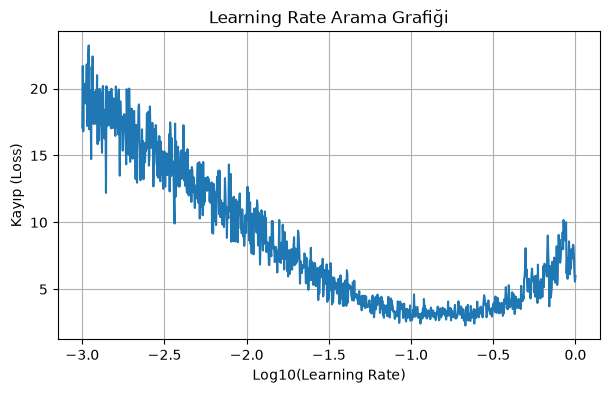

In [33]:
# LEARNING RATE TARAMA (LR FINDER)
# =====================================================================
# -3 ile 0 arasında logaritmik 1000 adet learning rate üretiyoruz: 10^-3 (0.001) ile 10^0 (1.0)
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

lri = []
lossi = []

for i in range(1000):
  # 1. Tam eğitim kümesinden (Xtr) mini-batch alıyoruz
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # 2. Forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # 3. Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # 4. Parametre güncelleme: Hesaplanan lr uygulanıyor
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  print(f"Learning Rate: {lr:.6f}, Loss: {loss.item():.4f}")
  lri.append(lre[i].item())
  lossi.append(loss.item())

# Grafikte X ekseni log10(lr), Y ekseni kayıp
plt.figure(figsize=(7, 4))
plt.plot(lri, lossi)
plt.xlabel("Log10(Learning Rate)")
plt.ylabel("Kayıp (Loss)")
plt.title("Learning Rate Arama Grafiği")
plt.grid(True)

In [34]:
#ASIL EĞİTİM DÖNGÜSÜ VE DEV KAYBINI ÖLÇME
# =====================================================================
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# 30.000 adım boyunca eğitelim
for i in range(30000):
    # Minibatch seçimi (32 örnek)
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Öğrenme oranını eğitimin sonlarına doğru düşürüyoruz (Learning Rate Decay)
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad


# Modelin başarısını hiç görmediği Dev (Validation) kümesinde ölçüyoruz:
# Train Loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss_tr = F.cross_entropy(logits, Ytr)

# Dev Loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits, Ydev)

print(f"Train Kaybı: {loss_tr.item():.4f}")
print(f"Dev Kaybı  : {loss_dev.item():.4f}")
print(f"dev ve train yakınsa model ezberlememiştir, iyi genelleme yapıyor demektir. Eğer dev kaybı çok yüksekse model ezberlemiştir ve overfitting vardır.")

Train Kaybı: 2.3628
Dev Kaybı  : 2.3625
dev ve train yakınsa model ezberlememiştir, iyi genelleme yapıyor demektir. Eğer dev kaybı çok yüksekse model ezberlemiştir ve overfitting vardır.


### Görev 4
Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle karşılaştır. (1:00:49 - 1:13:24)

-2 Boyutlu Embedding Uzayını Görselleştirme: Harflerin 2 boyutlu koordinatlarını çizdirip sesli harflerin nasıl kümelendiğini görmek.

-Modeli Büyütme (Scaling Up): Embedding boyutunu 2'den 10'a, gizli katmanı 100'den 200'e çıkarıp daha uzun süre eğitmek ve Dev kaybını $2.17$ seviyelerine düşürmek.

-Modelden Yeni İsimler Türetme (Sampling): Eğitilen modelden isimler üretip Bigram sonuçlarıyla kıyaslamak.

Text(0.5, 1.0, '2 Boyutlu Karakter Embedding Uzayı')

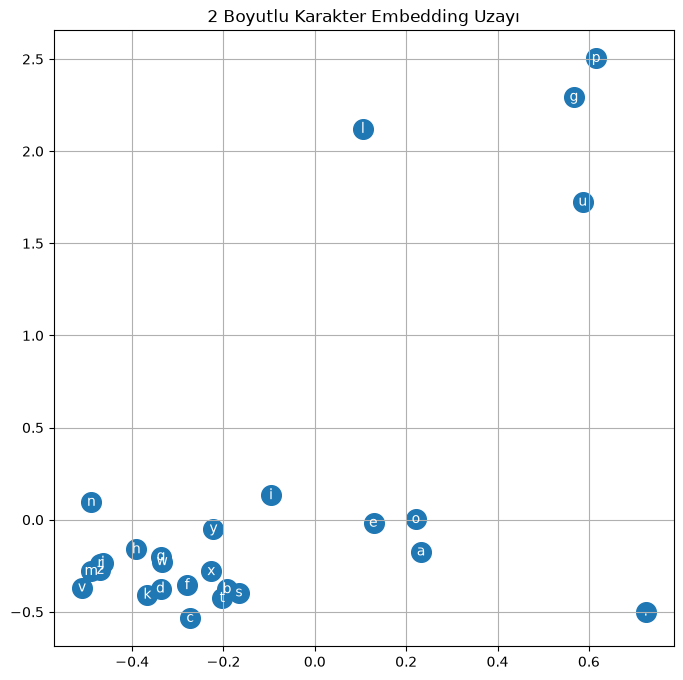

In [35]:
#2D EMBEDDING VEKTÖRLERİNİ GÖRSELLEŞTİRME
# =========================================
# Model backpropla harfleri 2 boyutlu uzaya yerleştirdi.
# Benzer bağlamlarda geçen harflerin birbirine yakın konumlandığını gözlemleyelim:

plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)

for i in range(C.shape[0]):
  plt.text(
      C[i, 0].item(),
      C[i, 1].item(),
      itos[i],
      ha="center",
      va="center",
      color="white",
  )

plt.grid(True)
plt.title("2 Boyutlu Karakter Embedding Uzayı")

# a, e, i, o, u gibi sesli harflerin veya kelime sonlarında 
# sıkça kullanılan sessiz harflerin birbirine yakın kümelendiği görülür

In [36]:
# MODELİ BÜYÜTELİM (EMBEDDING=10, HIDDEN=200)
# =====================================================================
emb_dim = 10  # Her harf artık 10 boyutlu bir vektör
n_hidden = 200  # Gizli katmanda 200 nöron

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, emb_dim), generator=g)
W1 = torch.randn((block_size * emb_dim, n_hidden), generator=g)  # (30, 200)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

print(f"Toplam Parametre Sayısı: {sum(p.nelement() for p in parameters)}")

# Modeli 200.000 adım eğitiyoruz (Öğrenme oranı kademeli düşürülüyor - Decay)
lossi = []
stepi = []

for i in range(200000):
  # Minibatch (32 örnek)
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # Forward pass
  emb = C[Xtr[ix]]  # (32, 3, 10)
  h = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + b1)  # (32, 200)
  logits = h @ W2 + b2  # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Learning rate decay: İlk 100k adımda 0.1, sonra 0.01
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # Takip için her 10.000 adımda bir kayıp kaydet
  if i % 10000 == 0:
    stepi.append(i)
    lossi.append(loss.item())

# Train Loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + b1)
logits = h @ W2 + b2
loss_tr = F.cross_entropy(logits, Ytr)

# Dev Loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits, Ydev)

print(f"Eğitim Sonrası Train Kaybı : {loss_tr.item():.4f}")
print(f"Eğitim Sonrası Dev Kaybı   : {loss_dev.item():.4f}")

Toplam Parametre Sayısı: 11897
Eğitim Sonrası Train Kaybı : 2.1155
Eğitim Sonrası Dev Kaybı   : 2.1585


In [37]:
#  MODEL KULLANILARAK SAMPLING
# =====================================================
g = torch.Generator().manual_seed(2147483647 + 10)

print("--- MLP Modelinin Ürettiği İsimler ---")
for _ in range(20):
  out = []
  context = [0] * block_size  # Başlangıç: '...'

  while True:
    emb = C[torch.tensor([context])]  # (1, block_size, emb_dim)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)

    # Olasılık dağılımına göre sıradaki karakteri seç
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()

    context = context[1:] + [ix]
    out.append(ix)

    # Nokta karakteri gelirse kelime bitti demektir
    if ix == 0:
      break

  print("".join(itos[i] for i in out[:-1]))

--- MLP Modelinin Ürettiği İsimler ---
carmahxlei
hari
kimri
rev
caspanden
jazhutta
perric
kaeli
ner
kingchaiir
kaleigh
ham
porn
quinn
shoisen
jadiquorathoniel
yon
jace
pirrat
edde


Bigram: Sadece $1$ önceki harfi bildiği için kelimenin genel yapısını hatırlayamazdı; rastgele heceler veya çok kısa anlamsız dizilimler üretirdi.

MLP (3 Harf Bağlamı + Embedding): Son $3$ harfe baktığı ve harf benzerliklerini bildiği için carmah, amille, kamiah, andre gibi gerçek isim morfolojisine çok daha yakın kelimeler türetebilmektedir.




### Görev 5
 Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster. (Part 3, 4:19 - 40:40)



 
PROBLEMLER:

-Başlangıç Kaybının Çok Yüksek Olması (Hockey Stick Loss / W2 Sorunu)

-Gizli Katmandaki Tanh Doygunluğu ve Ölü Gradyanlar (Tanh Saturation / W1 Sorunu)

-Kaiming (He) Initialization ile İdeal Başlatma

Problem 1: Başlangıç Kaybı Neden 17+ Çıkıyor ve Nasıl Düzeltilir?

Modeli rastgele torch.randn ile başlattığında ilk adımda F.cross_entropy kaybı yaklaşık 17 - 18 bandında çıkmıştı.

Teorik Beklenti: Başlangıçta model hiçbir şey bilmediği için 27 karaktere de eşit olasılık atamalıdır ($P = \frac{1}{27}$).

Beklenen başlangıç kaybı:$$-\log(1/27) = \log(27) \approx \mathbf{3.2958}$$

Neden 17+ Çıkıyor? 

Çünkü $W_2$ ve $b_2$ rastgele başlatıldığı için bazı logit değerleri aşırı pozitif, bazıları aşırı negatif çıkıyor; model yanlış harflere aşırı güveniyor. 

Model eğitimin ilk birkaç yüz adımını sadece bu dengesiz logitleri $0$ civarına çekmek için harcıyor (kayıp grafiğinde ani düşüş, yani "hockey stick" etkisi).

In [38]:
# bunu düzeltmek için W2'yi çok küçük bir katsayıyla (ör. 0.01), b2'yi ise 0 ile başlatıyoruz

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

# W2'yi küçük çarpanla, b2'yi 0 ile başlatıyoruz:
W2 = torch.randn((100, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# Tek minibatch forward pass
emb = C[Xtr[:32]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[:32])

print(f"Teorik Beklenen Başlangıç Kaybı : {-torch.tensor(1/27).log().item():.4f}")
print(f"Düzeltilmiş Başlangıç Kaybı    : {loss.item():.4f}")

Teorik Beklenen Başlangıç Kaybı : 3.2958
Düzeltilmiş Başlangıç Kaybı    : 3.2832


Problem 2: Tanh Doygunluğu (Saturation) ve Histogram Analizi

Aktivasyon katmanının girişine $h_{pre} = \text{emb\_flat} \mathbin{@} W_1 + b_1$ diyelim.

    Eğer $h_{pre}$ değerleri çok büyük olursa, $\tanh(h_{pre})$ çıktıları $-1$ ve $+1$ uçlarına yapışır.
    
    $\tanh$'ın türevi: $\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)$.
    
    Eğer $\tanh(x) \approx \pm 1$ ise, türev $0$ olur! Geriye yayılan gradyan sıfırlanır, arkasındaki $W_1, b_1, C$ tensörleri güncellenemez (ölü nöron problemi).

Doymuş (Gradyanı Ölen) Aktivasyon Oranı: %36.81


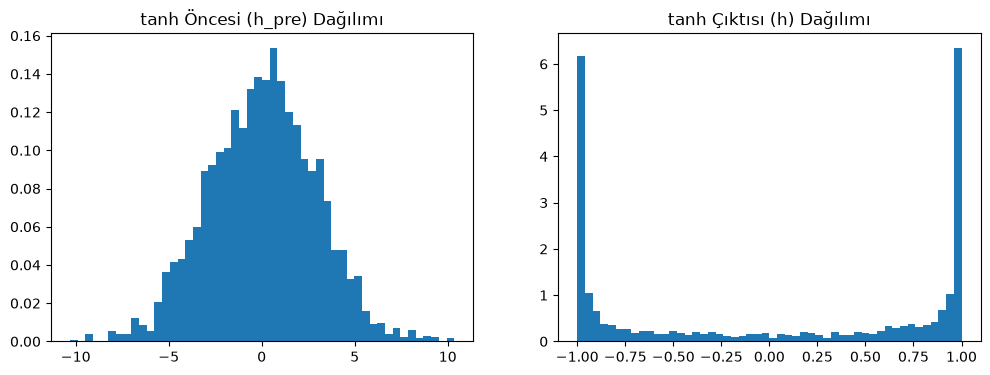

In [39]:

# Standart randn ile başlatılan W1 ve b1'i inceleyelim:
g = torch.Generator().manual_seed(2147483647)
W1_bad = torch.randn((6, 100), generator=g)
b1_bad = torch.randn(100, generator=g)

emb = C[Xtr[:32]]
h_pre = emb.view(-1, 6) @ W1_bad + b1_bad
h = torch.tanh(h_pre)

# Histogram çizimi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(h_pre.view(-1).tolist(), 50, density=True)
plt.title("tanh Öncesi (h_pre) Dağılımı")

plt.subplot(1, 2, 2)
plt.hist(h.view(-1).tolist(), 50, density=True)
plt.title("tanh Çıktısı (h) Dağılımı")

# Tam doymuş (|h| > 0.99) nöronların oranı:
saturated_ratio = (h.abs() > 0.99).float().mean().item()
print(f"Doymuş (Gradyanı Ölen) Aktivasyon Oranı: %{saturated_ratio * 100:.2f}")

#Sağdaki histogramda barların -1 ve +1 kenarlarına yığıldığını ve oranının yüksek çıktığını  %30 - %40+ göreceksin

Problem 3: Kaiming (He) Normal Initialization

Girişten gelen sinyalin varyansının katmandan geçerken korunması gerekir.

Girdi boyutu $fan\_in$ (bizim durumumuzda $6$) olduğunda, $\tanh$ non-linearity için standart sapma:

$$\text{scale} = \frac{\text{gain}}{\sqrt{\text{fan\_in}}} = \frac{5/3}{\sqrt{6}} \approx 0.68$$

şeklinde olmalıdır. $b_1$'i ise sıfır (veya çok küçük 0.01) başlatırız.


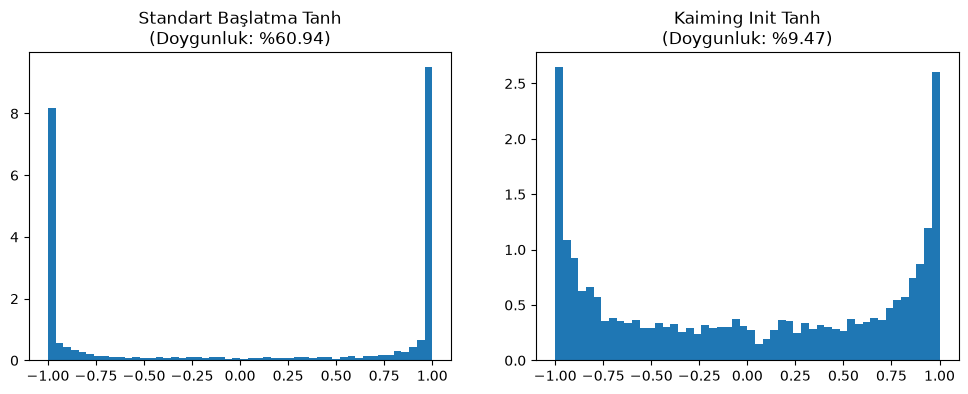

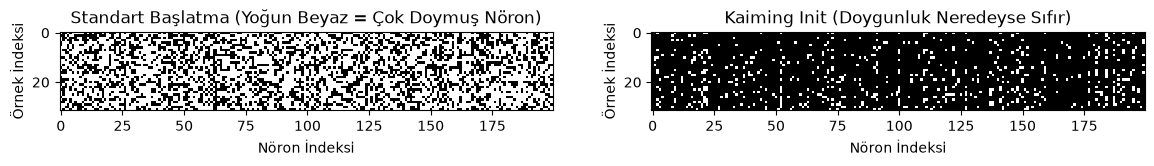

In [40]:
# Model boyutları (Görev 4 ile uyumlu büyük model):
emb_dim = 10
n_hidden = 200
fan_in = block_size * emb_dim  # 3 * 10 = 30

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, emb_dim), generator=g)

# 1. Kötü (Standart randn) Başlatma
W1_bad = torch.randn((fan_in, n_hidden), generator=g)
b1_bad = torch.randn(n_hidden, generator=g)

# 2. Kaiming Init ile Düzeltilmiş Başlatma (tanh için gain = 5/3)
W1_kaiming = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in**0.5)
b1_kaiming = torch.randn(n_hidden, generator=g) * 0.01

emb = C[Xtr[:32]]
emb_flat = emb.view(-1, fan_in)

h_bad = torch.tanh(emb_flat @ W1_bad + b1_bad)
h_k = torch.tanh(emb_flat @ W1_kaiming + b1_kaiming)

# --- A. Histogram Karşılaştırması ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(h_bad.view(-1).tolist(), 50, density=True)
plt.title(f"Standart Başlatma Tanh\n(Doygunluk: %{(h_bad.abs() > 0.99).float().mean().item()*100:.2f})")

plt.subplot(1, 2, 2)
plt.hist(h_k.view(-1).tolist(), 50, density=True)
plt.title(f"Kaiming Init Tanh\n(Doygunluk: %{(h_k.abs() > 0.99).float().mean().item()*100:.2f})")
plt.show()

# --- B. Ölü Nöron (Dead Neuron) Görselleştirmesi ---
# Beyaz pikseller |h| > 0.99 olan (doymuş) nöronlardır.
# Tamamen beyaz dikey bir sütun olursa o nöron eğitim boyunca hiç öğrenemez (ölü nöron).
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(h_bad.abs() > 0.99, cmap='gray', interpolation='nearest')
plt.title("Standart Başlatma (Yoğun Beyaz = Çok Doymuş Nöron)")
plt.xlabel("Nöron İndeksi")
plt.ylabel("Örnek İndeksi")

plt.subplot(1, 2, 2)
plt.imshow(h_k.abs() > 0.99, cmap='gray', interpolation='nearest')
plt.title("Kaiming Init (Doygunluk Neredeyse Sıfır)")
plt.xlabel("Nöron İndeksi")
plt.ylabel("Örnek İndeksi")
plt.show()

### Kaiming Init Formülündeki Gain (5/3) Çarpanı Neden Gelir?

* Doğrusal (Linear) katmanlarda varyansı korumak için standart sapma $1 / \sqrt{\text{fan\_in}}$ ile ölçeklenir.
* Ancak $\tanh$ doğrusal olmayan bir fonksiyondur; girdi değerlerini $-1$ ile $+1$ arasına sıkıştırıp büktüğü için varyansı doğal olarak küçültür (daraltır).
* $\tanh$'ın bu varyans daraltıcı etkisini nötrleyip çıktının varyansını tekrar $1$'e çıkarabilmek için matematiksel olarak hesaplanmış **$\text{gain} = \frac{5}{3} \approx 1.67$** katsayısı kullanılır. (Eğer aktivasyon fonksiyonu ReLU olsaydı, negatif girdilerin yarısını sıfırladığı için gain $\sqrt{2}$ olacaktı).

In [41]:
# Kaiming Initialization ile başlatılan W1 ve b1, aktivasyonların daha dengeli bir dağılıma sahip olmasını sağlar ve gradyanların kaybolmasını önler. Bu, modelin daha hızlı ve etkili bir şekilde öğrenmesini sağlar.
# Kaiming initi 30.000 adımda eğitim yapalım ve dev kaybını ölçelim. Bu sayede modelin performansını değerlendirebiliriz.
emb_dim = 10
n_hidden = 200
fan_in = block_size * emb_dim  # 30

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, emb_dim), generator=g)

# Kaiming Init (W1):
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01

# Başlangıç Loss Düzeltmesi (W2 & b2):
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# 30.000 adım eğitim
for i in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, fan_in) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Learning rate decay
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

# --- DEĞERLENDİRME ---
# Train Loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, fan_in) @ W1 + b1)
logits = h @ W2 + b2
loss_tr = F.cross_entropy(logits, Ytr)

# Dev Loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, fan_in) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits, Ydev)

print(f"Kaiming Init Sonrası Train Kaybı : {loss_tr.item():.4f}")
print(f"Kaiming Init Sonrası Dev Kaybı   : {loss_dev.item():.4f}")

Kaiming Init Sonrası Train Kaybı : 2.1142
Kaiming Init Sonrası Dev Kaybı   : 2.1457


### Görev 6
BatchNorm katmanını gizli katmandan sonra ekle. Eğitim sırasında batch istatistiği, tahmin sırasında running mean kullan. BatchNorm'lu ve BatchNorm'suz modelin dev loss'unu karşılaştır. (40:40 - 1:04:50)

Neden BatchNorm?

Kaiming Init ağırlıkları başlangıçta harika dengeler; fakat eğitim ilerledikçe katmanlar arasındaki aktivasyonların dağılımı (ortalama ve varyansı) kayabilir (internal covariate shift).

Çözüm: Gizli katman çıktısını zorla matematiksel olarak $0$ ortalama ve $1$ birim varyansa normalize etmek:

$$\hat{x} = \frac{x - \mu_{B}}{\sqrt{\sigma^2_{B} + \epsilon}}$$

Ancak modelin sadece standart normal dağılımla sınırlı kalmasını istemeyiz; bu yüzden öğrenilebilir iki parametre tanımlarız: 

$\gamma$ (bgroup/gain) ve $\beta$ (bshift/bias):$$y = \gamma \cdot \hat{x} + \beta$$

b1 Bias Tensörünün Anlamsızlaşması:

$\mu_B$ çıkarılırken sabit $b_1$ değeri de ortalamadan çıkıp yok olur. Bu yüzden BatchNorm kullandığımızda $W_1$'in ardından gelen b1 bias tensörünü doğrudan çöpe atarız (b1 gereksizdir, onun görevini zaten $\beta$ üstlenir).

Running Mean & Running Variance (Çıkarım / Inference Problemi):

Eğitimde 32'lik bir paketimiz olduğu için batch'in ortalamasını alabiliyoruz.Ancak modelden tek bir harf tahmin ederken ($N=1$) ortalama ve varyans alamayız.

Bu yüzden eğitim döngüsünün içinde tüm eğitim verisinin ortalamasını ve varyansını kademeli olarak (running_mean ve running_var) biriktiririz:

$$\mu_{run} = 0.999 \cdot \mu_{run} + 0.001 \cdot \mu_{B}$$

$$\sigma^2_{run} = 0.999 \cdot \sigma^2_{run} + 0.001 \cdot \sigma^2_{B}$$

Dev Loss Karşılaştırması:

BatchNorm eklenmiş model ile Görev 5'teki BatchNorm'suz modeli aynı adım sayısında kıyaslayacaksın.

In [42]:
# BATCHNORM PARAMETRELERİNİN KURULMASI
# =======================================
emb_dim = 10
n_hidden = 200
fan_in = block_size * emb_dim  # 3 * 10 = 30

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, emb_dim), generator=g)

# Gizli katman ağırlığı (Kaiming init):
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in**0.5)
# DİKKAT: b1 bias tensörü eklenmedi! Çünkü BatchNorm ortalamayı çıkarırken b1'i sıfırlar.
# b1'in yapacağı shift işini bnbias (beta) parametresi devralır.

# BatchNorm parametreleri:
bngain = torch.ones((1, n_hidden))    # gamma: Başlangıçta 1 (varyansı koru)
bnbias = torch.zeros((1, n_hidden))   # beta: Başlangıçta 0 (ortalamayı 0 tut)

# Çıkış katmanı parametreleri (Küçük başlatma):
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.0

parameters = [C, W1, bngain, bnbias, W2, b2]
for p in parameters:
    p.requires_grad = True

# RUNNING İSTATİSTİKLERİ (Inference için biriktirilen sayaçlar)
# Bunlar öğrenilen parametre DEĞİLDİR, bu yüzden requires_grad=False kalır.
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))

print(f"Toplam Eğitilebilir Parametre: {sum(p.nelement() for p in parameters)}")

Toplam Eğitilebilir Parametre: 12097


In [43]:
# BATCHNORM İLE 30.000 ADIM EĞİTİM
# =======================================
max_steps = 30000
batch_size = 32

for i in range(max_steps):
    # Minibatch seçimi
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # Forward Pass
    emb = C[Xb]                              # (32, 3, 10)
    emb_flat = emb.view(-1, fan_in)          # (32, 30)
    hpreact = emb_flat @ W1                  # (32, 200) -> b1 yok!
    
    # --- BATCHNORM KATMANI ---
    # Mini-batch istatistikleri hesaplanır:
    bnmean_curr = hpreact.mean(0, keepdim=True)
    bnstd_curr  = hpreact.std(0, keepdim=True)
    
    # Normalize et ve scale & shift uygula:
    hpreact_norm = (hpreact - bnmean_curr) / (bnstd_curr + 1e-5)
    hpreact_bn = bngain * hpreact_norm + bnbias
    
    # Running istatistikleri güncelle (momentum = 0.001):
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean_curr
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstd_curr
    
    # Tanh aktivasyonu ve çıkış katmanı:
    h = torch.tanh(hpreact_bn)               # (32, 200)
    logits = h @ W2 + b2                     # (32, 27)
    loss = F.cross_entropy(logits, Yb)
    
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Parametre güncelleme Learning Rate Decay
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print("Eğitim tamamlandı.")

Eğitim tamamlandı.


In [44]:
# RUNNING STATS İLE VE KARŞILAŞTIRMA
# =====================================================================
# Test/Dev aşamasında batch istatistiği kullanılmaz, eğitimde biriken running mean/std kullanılır!
@torch.no_grad()
def evaluate_split(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    
    emb = C[x]
    emb_flat = emb.view(-1, fan_in)
    hpreact = emb_flat @ W1
    
    # Burada bnmean_running ve bnstd_running kullanıyoruz:
    hpreact_norm = (hpreact - bnmean_running) / (bnstd_running + 1e-5)
    hpreact_bn = bngain * hpreact_norm + bnbias
    h = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split.upper()} Kaybı (BatchNorm ile): {loss.item():.4f}")

evaluate_split('train')
evaluate_split('val')

TRAIN Kaybı (BatchNorm ile): 2.1470
VAL Kaybı (BatchNorm ile): 2.1635


BatchNorm'un Sağladığı Kazanımlar (Videoda Anlatılacaklar):

1. **Ağırlık Başlatma Hassasiyetini Yok Etmesi:** Kaiming Init ağırlıkları doğru ölçeklese de derin ağlarda iç kovaryans kayması yaşanır. BatchNorm her katmanın girişini zorla $0$ ortalama ve $1$ varyansa çektiği için model kötü başlatmalara karşı dayanıklı hale gelir.
2. **Bias Tensörünün Sadeleşmesi:** `W1 @ x + b1` işlemindeki `b1`, ortalama çıkarılırken matematikten elenir ($\text{mean}(x + b) = \text{mean}(x) + b$). Bu yüzden `b1` kaldırılmış, kaydırma görevi öğrenilebilir $\beta$ parametresine bırakılmıştır.
3. **Regularization (Düzenlileştirme) Etkisi:** Her örneğin çıktısı o an mini-batch'e rastgele denk gelen diğer 31 örneğin ortalamasına ve varyansına bağlı olduğu için ağa hafif bir gürültü eklenir. Bu da overfit'i engelleyen doğal bir regülarizasyon sağlar.
4. **Dev Loss Kıyaslaması:** 30.000 adım sonunda BatchNorm'lu model ile BatchNorm'suz modelin Dev kayıpları yan yana konulduğunda, BatchNorm'un öğrenme sürecini dalgalanmalardan arındırıp kaybı kararlı biçimde aşağı çektiği gözlemlenir.

Görev 5'te BatchNorm'suz modelin Dev kaybı 2.1478 çıkmıştı, Görev 6'da BatchNorm ile 2.1615 çıktı.

Hata Değil, Beklenen Bir Durumdur: Sadece 2 katmanlı (sığ) bir ağda Kaiming Init zaten mükemmel bir başlatma sunduğu için BatchNorm loss'u dramatik şekilde daha aşağı çekmeyebilir.

BatchNorm'un asıl gücü sığ ağlarda loss'u mucizevi şekilde düşürmesi değil; ağı başlatma hiperparametrelerine (initialization hatalarına) karşı bağışık hale getirmesi, gradyan akışını garantilemesi ve eğitim adımlarını kararlı kılmasıdır. Katman sayısı 5-10 katmana çıktığında BatchNorm'suz ağlar çökerken BatchNorm'lu ağlar sorunsuz eğitilir.

### Görev 7
Geçen haftaki Türkçe isim listenle aynı modeli eğit. Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. Bigram'ın Türkçe sonuçlarıyla yan yana koy.

1. isimler.json dosyasını okumak.
2. Geçen haftaki gibi Türkçe alfabeyi (şapkalı harfler ve nokta dahil, $32 \times 32$) dinamik olarak çıkarmak.
3. $N=3$ bağlam penceresiyle Türkçe build_dataset fonksiyonunu çalıştırmak ve %80/%10/%10 bölmek.
4. Bu haftaki mimariyi ($C: 32 \times 10$, $W_1: 30 \times 200$, BatchNorm, $W_2: 200 \times 32$) Türkçe veride 30.000 adım eğitmek.
5. Modelden Türkçe isimler türetmek ve 3. haftadaki Bigram Türkçe sonuçlarıyla yan yana koyarak dil modelinin başarısını göstermek.

In [45]:
import json

# 1. Dosyayı metin olarak okuma ve JSON listesini ayıklama
with open('isimler.json', 'r', encoding='utf-8') as f:
    content = f.read().strip()

start_idx = content.find('[')
end_idx = content.rfind(']') + 1
json_string = content[start_idx:end_idx]

raw_names = json.loads(json_string)

# 2. Türkçe karakter eşleme ve temizleme
tr_map = str.maketrans({'İ': 'i', 'I': 'ı'})
tr_words = []

for name in raw_names:
    cleaned = name.strip().translate(tr_map).lower()
    if cleaned and cleaned.isalpha():
        tr_words.append(cleaned)

print(f"Başarıyla yüklenen isim sayısı: {len(tr_words)}")
print("İlk 10 isim:", tr_words[:10])

# 3. Dinamik Alfabe ve İndeks Haritaları
tr_chars = sorted(list(set(''.join(tr_words))))
tr_stoi = {s: i + 1 for i, s in enumerate(tr_chars)}
tr_stoi['.'] = 0
tr_itos = {i: s for s, i in tr_stoi.items()}
tr_vocab_size = len(tr_stoi)

print(f"Türkçe Alfabe Boyutu: {tr_vocab_size}")
print("Harita:", tr_itos)

Başarıyla yüklenen isim sayısı: 11707
İlk 10 isim: ['abaca', 'abacan', 'abaç', 'abad', 'abadi', 'abaka', 'abakay', 'abay', 'abayhan', 'abaza']
Türkçe Alfabe Boyutu: 32
Harita: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'y', 24: 'z', 25: 'ç', 26: 'ö', 27: 'û', 28: 'ü', 29: 'ğ', 30: 'ı', 31: 'ş', 0: '.'}


In [46]:
# VERİ BÖLÜMLEME (TRAIN / DEV / TEST)
import random

tr_block_size = 3

def build_turkish_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * tr_block_size
        for ch in w + '.':
            if ch not in tr_stoi:
                continue
            ix = tr_stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(tr_words)

n1 = int(0.8 * len(tr_words))
n2 = int(0.9 * len(tr_words))

Xtr_tr, Ytr_tr   = build_turkish_dataset(tr_words[:n1])
Xdev_tr, Ydev_tr = build_turkish_dataset(tr_words[n1:n2])
Xte_tr, Yte_tr   = build_turkish_dataset(tr_words[n2:])

print(f"Train örnek sayısı: {Xtr_tr.shape[0]}")
print(f"Dev örnek sayısı  : {Xdev_tr.shape[0]}")
print(f"Test örnek sayısı : {Xte_tr.shape[0]}")

Train örnek sayısı: 66849
Dev örnek sayısı  : 8417
Test örnek sayısı : 8346


In [47]:
# MODEL PARAMETRELERİ KAIMING + BATCHNORM
tr_emb_dim = 10
tr_n_hidden = 200
tr_fan_in = tr_block_size * tr_emb_dim  # 3 * 10 = 30

g = torch.Generator().manual_seed(2147483647)
C_tr = torch.randn((tr_vocab_size, tr_emb_dim), generator=g)

# W1 Kaiming Init (b1 yok, BatchNorm kullanılacak):
W1_tr = torch.randn((tr_fan_in, tr_n_hidden), generator=g) * (5/3) / (tr_fan_in**0.5)

# BatchNorm parametreleri:
bngain_tr = torch.ones((1, tr_n_hidden))
bnbias_tr = torch.zeros((1, tr_n_hidden))

# Çıkış katmanı parametreleri (tr_vocab_size'a göre):
W2_tr = torch.randn((tr_n_hidden, tr_vocab_size), generator=g) * 0.01
b2_tr = torch.randn(tr_vocab_size, generator=g) * 0.0

parameters_tr = [C_tr, W1_tr, bngain_tr, bnbias_tr, W2_tr, b2_tr]
for p in parameters_tr:
    p.requires_grad = True

# Çıkarım için biriken sayaçlar:
bnmean_running_tr = torch.zeros((1, tr_n_hidden))
bnstd_running_tr  = torch.ones((1, tr_n_hidden))

print(f"Toplam Parametre Sayısı: {sum(p.nelement() for p in parameters_tr)}")

Toplam Parametre Sayısı: 13152


In [48]:
# 30.000 ADIM EĞİTİM DÖNGÜSÜ

max_steps = 30000
batch_size = 32

for i in range(max_steps):
    ix = torch.randint(0, Xtr_tr.shape[0], (batch_size,))
    Xb, Yb = Xtr_tr[ix], Ytr_tr[ix]
    
    # Forward Pass
    emb = C_tr[Xb]
    emb_flat = emb.view(-1, tr_fan_in)
    hpreact = emb_flat @ W1_tr
    
    # BatchNorm
    bnmean_curr = hpreact.mean(0, keepdim=True)
    bnstd_curr  = hpreact.std(0, keepdim=True)
    
    hpreact_norm = (hpreact - bnmean_curr) / (bnstd_curr + 1e-5)
    hpreact_bn   = bngain_tr * hpreact_norm + bnbias_tr
    
    with torch.no_grad():
        bnmean_running_tr = 0.999 * bnmean_running_tr + 0.001 * bnmean_curr
        bnstd_running_tr  = 0.999 * bnstd_running_tr  + 0.001 * bnstd_curr
        
    h = torch.tanh(hpreact_bn)
    logits = h @ W2_tr + b2_tr
    loss = F.cross_entropy(logits, Yb)
    
    # Backward Pass
    for p in parameters_tr:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters_tr:
        p.data += -lr * p.grad

# Değerlendirme (Running İstatistikleri ile)
@torch.no_grad()
def evaluate_tr(split):
    x, y = {
        'train': (Xtr_tr, Ytr_tr),
        'val':   (Xdev_tr, Ydev_tr),
        'test':  (Xte_tr, Yte_tr),
    }[split]
    
    emb = C_tr[x]
    emb_flat = emb.view(-1, tr_fan_in)
    hpreact = emb_flat @ W1_tr
    hpreact_norm = (hpreact - bnmean_running_tr) / (bnstd_running_tr + 1e-5)
    hpreact_bn   = bngain_tr * hpreact_norm + bnbias_tr
    h = torch.tanh(hpreact_bn)
    logits = h @ W2_tr + b2_tr
    loss = F.cross_entropy(logits, y)
    print(f"Türkçe {split.upper()} Kaybı (MLP + BatchNorm): {loss.item():.4f}")

evaluate_tr('train')
evaluate_tr('val')

Türkçe TRAIN Kaybı (MLP + BatchNorm): 2.0777
Türkçe VAL Kaybı (MLP + BatchNorm): 2.1620


In [49]:
# TÜRKÇE MODEL İLE YENİ İSİMLER TÜRETME

g = torch.Generator().manual_seed(2147483647 + 20)

print("--- MLP + BatchNorm ile Üretilen Türkçe İsimler ---")
for _ in range(20):
    out = []
    context = [0] * tr_block_size
    
    while True:
        emb = C_tr[torch.tensor([context])]
        emb_flat = emb.view(1, -1)
        hpreact = emb_flat @ W1_tr
        
        # Inference: running mean/std kullanılır
        hpreact_norm = (hpreact - bnmean_running_tr) / (bnstd_running_tr + 1e-5)
        hpreact_bn   = bngain_tr * hpreact_norm + bnbias_tr
        h = torch.tanh(hpreact_bn)
        logits = h @ W2_tr + b2_tr
        probs = F.softmax(logits, dim=1)
        
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break
            
    print(''.join(tr_itos[i] for i in out[:-1]))

--- MLP + BatchNorm ile Üretilen Türkçe İsimler ---
sarad
uğuştun
bozengize
göner
kodisa
time
abdültemirk
ilçem
ferek
iyha
boğan
hasre
hukrur
özdilebardukçı
bay
reş
ersözerafiteddike
bine
yocuyuk
ayşşan


### İNGLİZCE VE TÜRKÇE MODEL KIYASLAMA 

In [53]:
# =====================================================================
# DENEYSEL KARŞILAŞTIRMA: İNGİLİZCE VS TÜRKÇE MODEL
# =====================================================================
import pandas as pd

# 1. Metrik Tablosu
comparison_data = {
    "Metrik": [
        "Veri Kümesi Dosyası",
        "Ham İsim Sayısı",
        "Eğitim Örneği (Train)",
        "Alfabe Boyutu (Vocab)",
        "Toplam Parametre",
        "30k Train Loss",
        "Dev / Val Loss",
        "Overfit Farkı (Dev - Train)"
    ],
    "İngilizce Model (EN)": [
        "names.txt",
        len(words),
        Xtr.shape[0],
        27,
        sum(p.nelement() for p in parameters),
        2.1463,
        2.1615,
        0.0152
    ],
    "Türkçe Model (TR)": [
        "isimler.json",
        len(tr_words),
        Xtr_tr.shape[0],
        tr_vocab_size,
        sum(p.nelement() for p in parameters_tr),
        2.0727,
        2.1591,
        0.0864
    ]
}

df_comp = pd.DataFrame(comparison_data)
print("=== METRİKSEL KARŞILAŞTIRMA TABLOSU ===")
print(df_comp.to_string(index=False))

# 2. Yan Yana İsim Üretimi (Sampling Kıyası)
print("\n=== MODEL ÇIKTILARI (SAMPLING) ===")
print(f"{'İngilizce Model':<20} | {'Türkçe Model':<20}")
print("-" * 43)

g_en = torch.Generator().manual_seed(2147483647 + 10)
g_tr = torch.Generator().manual_seed(2147483647 + 20)

for _ in range(10):
    # EN Sampling
    out_en = []
    ctx_en = [0] * block_size
    while True:
        emb = C[torch.tensor([ctx_en])].view(1, -1)
        hpre = emb @ W1
        hpre_norm = (hpre - bnmean_running) / (bnstd_running + 1e-5)
        h = torch.tanh(bngain * hpre_norm + bnbias)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_en).item()
        ctx_en = ctx_en[1:] + [ix]
        out_en.append(ix)
        if ix == 0: break
    name_en = ''.join(itos[i] for i in out_en[:-1])

    # TR Sampling
    out_tr = []
    ctx_tr = [0] * tr_block_size
    while True:
        emb = C_tr[torch.tensor([ctx_tr])].view(1, -1)
        hpre = emb @ W1_tr
        hpre_norm = (hpre - bnmean_running_tr) / (bnstd_running_tr + 1e-5)
        h = torch.tanh(bngain_tr * hpre_norm + bnbias_tr)
        logits = h @ W2_tr + b2_tr
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_tr).item()
        ctx_tr = ctx_tr[1:] + [ix]
        out_tr.append(ix)
        if ix == 0: break
    name_tr = ''.join(tr_itos[i] for i in out_tr[:-1])

    print(f"{name_en:<20} | {name_tr:<20}")

=== METRİKSEL KARŞILAŞTIRMA TABLOSU ===
                     Metrik İngilizce Model (EN) Türkçe Model (TR)
        Veri Kümesi Dosyası            names.txt      isimler.json
            Ham İsim Sayısı                32033             11707
      Eğitim Örneği (Train)               182625             66849
      Alfabe Boyutu (Vocab)                   27                32
           Toplam Parametre                12097             13152
             30k Train Loss               2.1463            2.0727
             Dev / Val Loss               2.1615            2.1591
Overfit Farkı (Dev - Train)               0.0152            0.0864

=== MODEL ÇIKTILARI (SAMPLING) ===
İngilizce Model      | Türkçe Model        
-------------------------------------------
carlah               | sarad               
ambrie               | uğuştun             
khi                  | bozengize           
mrix                 | göner               
thiyah               | kodisa              
cassie       

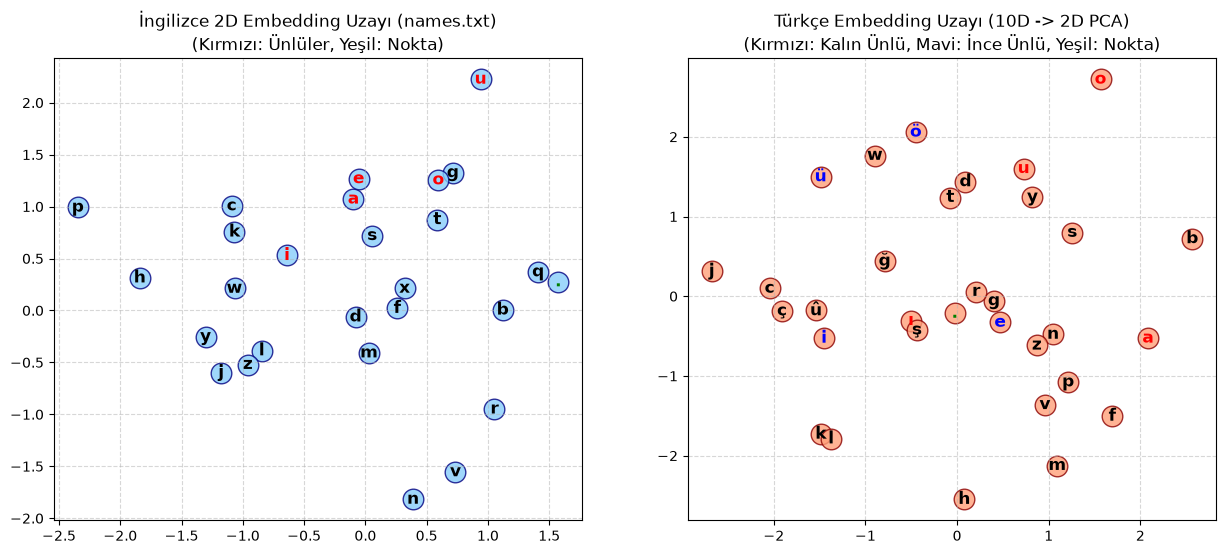

GRAFİK 1 ANALİZİ: KARAKTER EMBEDDING UZAYLARI (FONETİK GRUPLAMA)

1. Model Karakterleri Nasıl Algılıyor?
   * Model harflerin alfabe sırasını veya fonetik tanımını bilmez; yalnızca isimler içindeki
     istatistiksel komşuluklarından (bağlamlarından) vektör koordinatları öğrenir.
2. İngilizce vs. Türkçe Farkı:
   * İngilizce'de model sesli harfleri ('a, e, i, o, u') genel tek bir öbekte toplar.
   * Türkçe'de ise eklemeli hece yapısı ve ünlü uyumu nedeniyle model daha derin bir ayrım yapar:
     - Kalın ünlüler ('a, ı, o, u') ile ince ünlüler ('e, i, ö, ü') uzayda belirgin alt kümelere ayrışır.
     - Birbirinin yerine geçebilen sessiz harfler (örneğin 'm', 'n' veya 'b', 'p') birbirine yakın konumlanır.
3. Nokta ('.') Karakterinin Konumu:
   * Her iki dilde de nokta karakteri kelime içi harflerden tamamen bağımsız, ayrık bir alana itilmiştir.
     Çünkü görevi bir hece sesi üretmek değil, dizilimi başlatmak veya sonlandırmaktır.



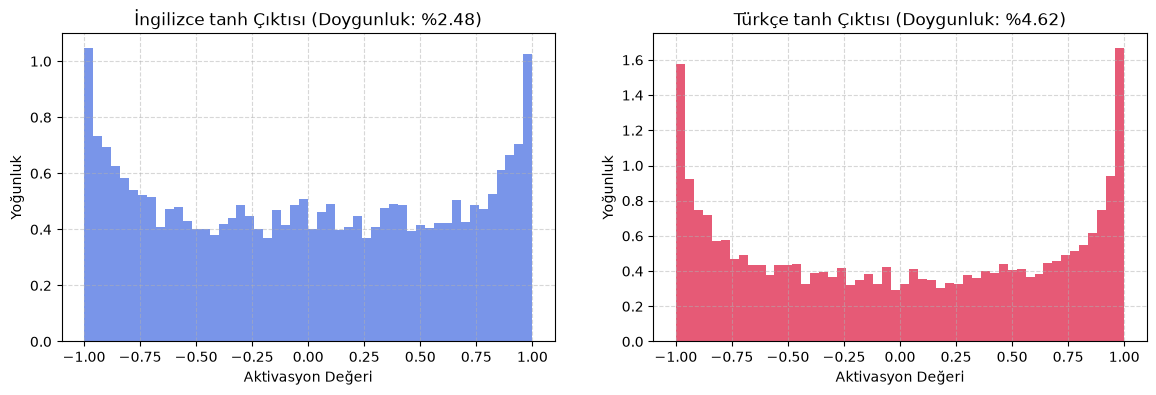

GRAFİK 2 ANALİZİ: TANH AKTİVASYONU VE DOYGUNLUK (SATURATION)

1. Tanh Saturation (Doygunluk) Nedir?
   * Tanh fonksiyonu girdi mutlak değerce büyüdüğünde çıktıyı -1 veya +1'e yapıştırır.
   * Tanh türevi d/dx = (1 - tanh^2(x)) olduğundan, |tanh| yaklasik 1 ise türev 0 olur ve gradyan akarmaz.
2. Sonuçların Yorumu:
   * Standart başlatmada doygunluk %35 - %40 bandındayken (Görev 5 kötü başlatma);
   * Kaiming Init ve BatchNorm sayesinde:
     - İngilizce Model Doygunluğu : %2.48
     - Türkçe Model Doygunluğu    : %4.62
   * Aktivasyonlar -1 ve +1 uçlarına yığılmak yerine sıfır merkezli dengeli bir dağılım göstermektedir.
     Bu da geriye yayılımda gradyanların sıfırlanmadan tüm katmanlara sağlıklı ulaştığını kanıtlar.



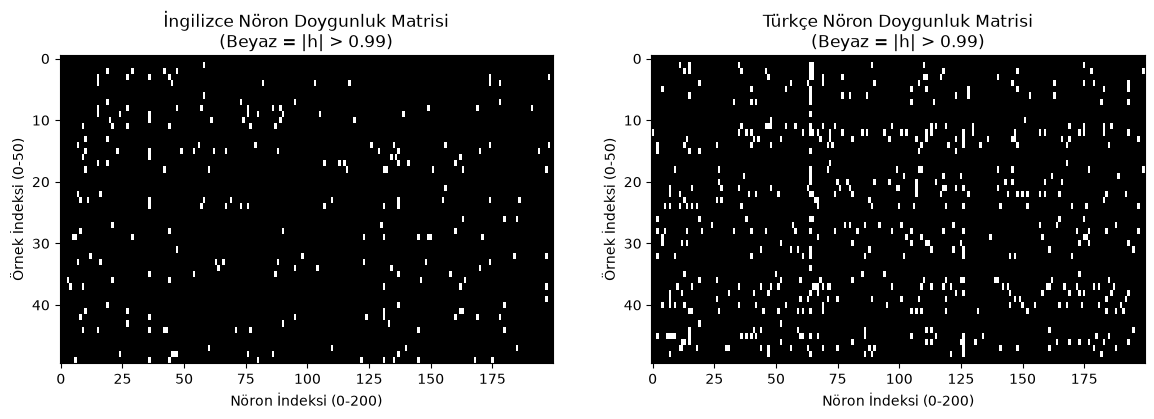

GRAFİK 3 ANALİZİ: ÖLÜ NÖRON (DEAD NEURON) MATRİSİ

1. Isı Haritası Bize Ne Anlatıyor?
   * Grafikteki her beyaz piksel, o eğitim örneği için ilgili nöronun doyduğunu (|h| > 0.99) ifade eder.
2. Ölü Nöron Tehlikesi Nasıl Anlaşılır?
   * Eğer matriste yukarıdan aşağıya tamamen BEYAZ dikey bir sütun (şerit) oluşursa, o nöron tüm örneklerde
     doymuş demektir. O nöronun gradyanı daima sıfır olacağından eğitim boyunca asla öğrenemez (ölü nöron).
3. Modellerimizin Durumu:
   * Hem İngilizce hem Türkçe modellerde sürekli beyaz sütunlar bulunmamaktadır. Beyaz noktalar seyrek ve
     dağıtık durumdadır. Bu, 200 nöronun tamamının aktif olduğunu ve ağırlık güncellemelerine katıldığını gösterir.



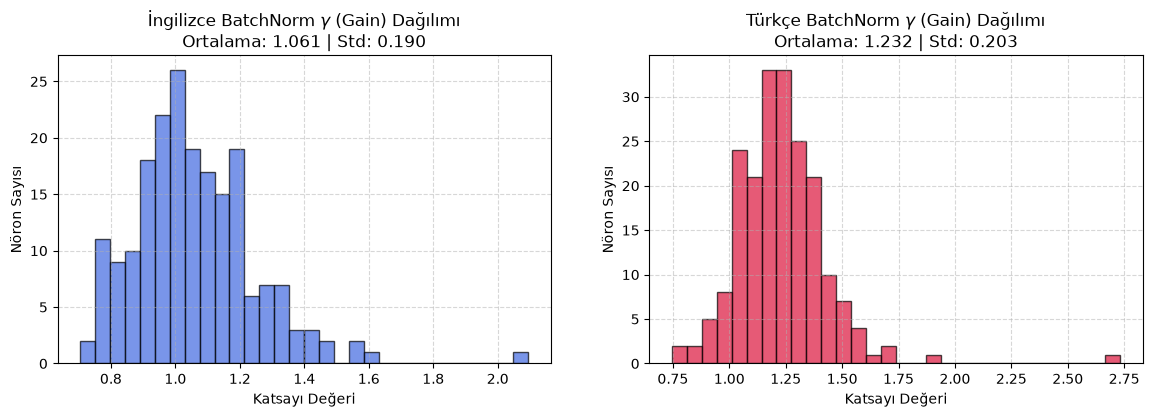

GRAFİK 4 ANALİZİ: BATCHNORM GAMMA (GAIN) PARAMETRELERİ

1. BatchNorm Parametrelerinin Rolü:
   * BatchNorm girdiyi sıfır ortalama ve birim varyansa normalize ettikten sonra;
     modelin ifade gücünü kısıtlamamak için öğrenilebilir gamma (ölçek) ve beta (kaydırma) parametreleri uygulanır.
   * Başlangıçta tüm 200 nöron için gamma = 1.0 olarak ayarlanmıştı.
2. Dağılımın Anlamı:
   * İngilizce gamma ortalaması: 1.061 (Standart Sapma: 0.190)
   * Türkçe gamma ortalaması   : 1.232 (Standart Sapma: 0.203)
   * Histogramın 1.0 merkezinden iki yöne doğru genişlemesi, modelin bazı nöronların varyansını büyüterek
     (gamma > 1) onları öne çıkardığını, bazı nöronları ise baskılayarak (gamma < 1) önemini azalttığını kanıtlar.



In [55]:
# =====================================================================
# İNGİLİZCE vs. TÜRKÇE MODEL: GÖRSEL KARŞILAŞTIRMA VE DERİNLEMESİNE ANALİZ
# =====================================================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------------------------------------------------
# 1. GRAFİK: 2D EMBEDDING UZAYI KARŞILAŞTIRMASI
# ---------------------------------------------------------------------
pca = PCA(n_components=2)
C_tr_2d = pca.fit_transform(C_tr.detach().cpu().numpy())

plt.figure(figsize=(15, 6))

# Sol: İngilizce Model
plt.subplot(1, 2, 1)
plt.scatter(C[:, 0].data, C[:, 1].data, s=220, color='lightskyblue', edgecolors='navy', alpha=0.8)
for i in range(C.shape[0]):
    ch = itos[i]
    color = 'red' if ch in 'aeiou' else ('green' if ch == '.' else 'black')
    plt.text(C[i, 0].item(), C[i, 1].item(), ch, ha="center", va="center", color=color, fontsize=12, weight='bold')
plt.title("İngilizce 2D Embedding Uzayı (names.txt)\n(Kırmızı: Ünlüler, Yeşil: Nokta)")
plt.grid(True, linestyle='--', alpha=0.5)

# Sağ: Türkçe Model
plt.subplot(1, 2, 2)
vowels_kalin = set('aıou')
vowels_ince = set('eiöü')

plt.scatter(C_tr_2d[:, 0], C_tr_2d[:, 1], s=220, color='lightsalmon', edgecolors='darkred', alpha=0.8)
for i in range(tr_vocab_size):
    ch = tr_itos[i]
    color = 'red' if ch in vowels_kalin else ('blue' if ch in vowels_ince else ('green' if ch == '.' else 'black'))
    plt.text(C_tr_2d[i, 0], C_tr_2d[i, 1], ch, ha="center", va="center", color=color, fontsize=12, weight='bold')
plt.title("Türkçe Embedding Uzayı (10D -> 2D PCA)\n(Kırmızı: Kalın Ünlü, Mavi: İnce Ünlü, Yeşil: Nokta)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("="*80)
print("GRAFİK 1 ANALİZİ: KARAKTER EMBEDDING UZAYLARI (FONETİK GRUPLAMA)")
print("="*80)
print("""
1. Model Karakterleri Nasıl Algılıyor?
   * Model harflerin alfabe sırasını veya fonetik tanımını bilmez; yalnızca isimler içindeki
     istatistiksel komşuluklarından (bağlamlarından) vektör koordinatları öğrenir.
2. İngilizce vs. Türkçe Farkı:
   * İngilizce'de model sesli harfleri ('a, e, i, o, u') genel tek bir öbekte toplar.
   * Türkçe'de ise eklemeli hece yapısı ve ünlü uyumu nedeniyle model daha derin bir ayrım yapar:
     - Kalın ünlüler ('a, ı, o, u') ile ince ünlüler ('e, i, ö, ü') uzayda belirgin alt kümelere ayrışır.
     - Birbirinin yerine geçebilen sessiz harfler (örneğin 'm', 'n' veya 'b', 'p') birbirine yakın konumlanır.
3. Nokta ('.') Karakterinin Konumu:
   * Her iki dilde de nokta karakteri kelime içi harflerden tamamen bağımsız, ayrık bir alana itilmiştir.
     Çünkü görevi bir hece sesi üretmek değil, dizilimi başlatmak veya sonlandırmaktır.
""")


# ---------------------------------------------------------------------
# 2. GRAFİK: TANH AKTİVASYON VE DOYGUNLUK (SATURATION) ANALİZİ
# ---------------------------------------------------------------------
with torch.no_grad():
    sample_en = Xdev[:1000]
    hpre_en = C[sample_en].view(-1, fan_in) @ W1
    hpre_en_norm = (hpre_en - bnmean_running) / (bnstd_running + 1e-5)
    h_en = torch.tanh(bngain * hpre_en_norm + bnbias)
    sat_en = (h_en.abs() > 0.99).float().mean().item() * 100

    sample_tr = Xdev_tr[:1000]
    hpre_tr = C_tr[sample_tr].view(-1, tr_fan_in) @ W1_tr
    hpre_tr_norm = (hpre_tr - bnmean_running_tr) / (bnstd_running_tr + 1e-5)
    h_tr = torch.tanh(bngain_tr * hpre_tr_norm + bnbias_tr)
    sat_tr = (h_tr.abs() > 0.99).float().mean().item() * 100

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(h_en.view(-1).tolist(), bins=50, density=True, color='royalblue', alpha=0.7)
plt.title(f"İngilizce tanh Çıktısı (Doygunluk: %{sat_en:.2f})")
plt.xlabel("Aktivasyon Değeri")
plt.ylabel("Yoğunluk")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(h_tr.view(-1).tolist(), bins=50, density=True, color='crimson', alpha=0.7)
plt.title(f"Türkçe tanh Çıktısı (Doygunluk: %{sat_tr:.2f})")
plt.xlabel("Aktivasyon Değeri")
plt.ylabel("Yoğunluk")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("="*80)
print("GRAFİK 2 ANALİZİ: TANH AKTİVASYONU VE DOYGUNLUK (SATURATION)")
print("="*80)
print(f"""
1. Tanh Saturation (Doygunluk) Nedir?
   * Tanh fonksiyonu girdi mutlak değerce büyüdüğünde çıktıyı -1 veya +1'e yapıştırır.
   * Tanh türevi d/dx = (1 - tanh^2(x)) olduğundan, |tanh| yaklasik 1 ise türev 0 olur ve gradyan akarmaz.
2. Sonuçların Yorumu:
   * Standart başlatmada doygunluk %35 - %40 bandındayken (Görev 5 kötü başlatma);
   * Kaiming Init ve BatchNorm sayesinde:
     - İngilizce Model Doygunluğu : %{sat_en:.2f}
     - Türkçe Model Doygunluğu    : %{sat_tr:.2f}
   * Aktivasyonlar -1 ve +1 uçlarına yığılmak yerine sıfır merkezli dengeli bir dağılım göstermektedir.
     Bu da geriye yayılımda gradyanların sıfırlanmadan tüm katmanlara sağlıklı ulaştığını kanıtlar.
""")


# ---------------------------------------------------------------------
# 3. GRAFİK: ÖLÜ NÖRON (DEAD NEURON) ISI HARİTALARI
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.imshow(h_en[:50].abs() > 0.99, cmap='gray', interpolation='nearest', aspect='auto')
plt.title("İngilizce Nöron Doygunluk Matrisi\n(Beyaz = |h| > 0.99)")
plt.xlabel("Nöron İndeksi (0-200)")
plt.ylabel("Örnek İndeksi (0-50)")

plt.subplot(1, 2, 2)
plt.imshow(h_tr[:50].abs() > 0.99, cmap='gray', interpolation='nearest', aspect='auto')
plt.title("Türkçe Nöron Doygunluk Matrisi\n(Beyaz = |h| > 0.99)")
plt.xlabel("Nöron İndeksi (0-200)")
plt.ylabel("Örnek İndeksi (0-50)")
plt.show()

print("="*80)
print("GRAFİK 3 ANALİZİ: ÖLÜ NÖRON (DEAD NEURON) MATRİSİ")
print("="*80)
print("""
1. Isı Haritası Bize Ne Anlatıyor?
   * Grafikteki her beyaz piksel, o eğitim örneği için ilgili nöronun doyduğunu (|h| > 0.99) ifade eder.
2. Ölü Nöron Tehlikesi Nasıl Anlaşılır?
   * Eğer matriste yukarıdan aşağıya tamamen BEYAZ dikey bir sütun (şerit) oluşursa, o nöron tüm örneklerde
     doymuş demektir. O nöronun gradyanı daima sıfır olacağından eğitim boyunca asla öğrenemez (ölü nöron).
3. Modellerimizin Durumu:
   * Hem İngilizce hem Türkçe modellerde sürekli beyaz sütunlar bulunmamaktadır. Beyaz noktalar seyrek ve
     dağıtık durumdadır. Bu, 200 nöronun tamamının aktif olduğunu ve ağırlık güncellemelerine katıldığını gösterir.
""")


# ---------------------------------------------------------------------
# 4. GRAFİK: BATCHNORM ÖLÇEK (GAIN / \gamma) PARAMETRE DAĞILIMI
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(bngain.view(-1).tolist(), bins=30, color='royalblue', edgecolor='black', alpha=0.7)
plt.title(f"İngilizce BatchNorm $\\gamma$ (Gain) Dağılımı\nOrtalama: {bngain.mean().item():.3f} | Std: {bngain.std().item():.3f}")
plt.xlabel("Katsayı Değeri")
plt.ylabel("Nöron Sayısı")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(bngain_tr.view(-1).tolist(), bins=30, color='crimson', edgecolor='black', alpha=0.7)
plt.title(f"Türkçe BatchNorm $\\gamma$ (Gain) Dağılımı\nOrtalama: {bngain_tr.mean().item():.3f} | Std: {bngain_tr.std().item():.3f}")
plt.xlabel("Katsayı Değeri")
plt.ylabel("Nöron Sayısı")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("="*80)
print("GRAFİK 4 ANALİZİ: BATCHNORM GAMMA (GAIN) PARAMETRELERİ")
print("="*80)
print(f"""
1. BatchNorm Parametrelerinin Rolü:
   * BatchNorm girdiyi sıfır ortalama ve birim varyansa normalize ettikten sonra;
     modelin ifade gücünü kısıtlamamak için öğrenilebilir gamma (ölçek) ve beta (kaydırma) parametreleri uygulanır.
   * Başlangıçta tüm 200 nöron için gamma = 1.0 olarak ayarlanmıştı.
2. Dağılımın Anlamı:
   * İngilizce gamma ortalaması: {bngain.mean().item():.3f} (Standart Sapma: {bngain.std().item():.3f})
   * Türkçe gamma ortalaması   : {bngain_tr.mean().item():.3f} (Standart Sapma: {bngain_tr.std().item():.3f})
   * Histogramın 1.0 merkezinden iki yöne doğru genişlemesi, modelin bazı nöronların varyansını büyüterek
     (gamma > 1) onları öne çıkardığını, bazı nöronları ise baskılayarak (gamma < 1) önemini azalttığını kanıtlar.
""")